# Online Retail II — Revenue Analysis

This notebook analyzes merchandise revenue performance across time, products, customers, and countries. Gross sales, cancellations, and estimated net revenue are reported separately to avoid overstating business performance.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid")

print("Pandas version:", pd.__version__)

Pandas version: 3.0.5


In [2]:
project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

data_path = (
    project_root
    / "data"
    / "processed"
    / "retail_transactions_clean.csv.gz"
)

print("Project root:", project_root)
print("Processed data path:", data_path)
print("Dataset exists:", data_path.exists())

Project root: c:\Users\hp\Documents\Customer-Revenue-Retention-Analytics
Processed data path: c:\Users\hp\Documents\Customer-Revenue-Retention-Analytics\data\processed\retail_transactions_clean.csv.gz
Dataset exists: True


In [3]:
column_types = {
    "invoice_no": "string",
    "stock_code": "string",
    "description": "string",
    "quantity": "int64",
    "unit_price": "float64",
    "customer_id": "Int64",
    "country": "string",
    "source_year": "string",
    "transaction_type": "category",
    "line_category": "category",
    "line_value": "float64",
    "data_quality_flag": "category",
    "analysis_eligible": "boolean",
}

transactions = pd.read_csv(
    data_path,
    compression="gzip",
    dtype=column_types,
    parse_dates=["invoice_date"],
)

print("Dataset shape:", transactions.shape)
print(
    "Date range:",
    transactions["invoice_date"].min(),
    "to",
    transactions["invoice_date"].max(),
)

display(transactions.head())

Dataset shape: (1033036, 14)
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,source_year,transaction_type,line_category,line_value,data_quality_flag,analysis_eligible
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,Year 2009-2010,Sale,Merchandise,83.40,Standard,True
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,Year 2009-2010,Sale,Merchandise,81.00,Standard,True
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,Year 2009-2010,Sale,Merchandise,81.00,Standard,True
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,Year 2009-2010,Sale,Merchandise,100.80,Standard,True
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,Year 2009-2010,Sale,Merchandise,30.00,Standard,True


## Analytical Scope and Executive KPIs

Primary revenue analysis includes eligible merchandise sales and merchandise cancellations. Gross sales, cancellation value, and estimated net merchandise revenue are calculated separately.

In [4]:
merchandise_activity = transactions.loc[
    transactions["line_category"].eq("Merchandise")
    & transactions["transaction_type"].isin(
        ["Sale", "Cancellation"]
    )
    & transactions["analysis_eligible"].eq(True)
].copy()

merchandise_activity["gross_sales_value"] = np.where(
    merchandise_activity["transaction_type"].eq("Sale"),
    merchandise_activity["line_value"],
    0.0,
)

merchandise_activity["cancellation_value"] = np.where(
    merchandise_activity["transaction_type"].eq("Cancellation"),
    merchandise_activity["line_value"].abs(),
    0.0,
)

merchandise_activity["net_value"] = (
    merchandise_activity["gross_sales_value"]
    - merchandise_activity["cancellation_value"]
)

merchandise_sales = merchandise_activity.loc[
    merchandise_activity["transaction_type"].eq("Sale")
].copy()

merchandise_cancellations = merchandise_activity.loc[
    merchandise_activity["transaction_type"].eq(
        "Cancellation"
    )
].copy()

print("Merchandise sales rows:", len(merchandise_sales))
print(
    "Merchandise cancellation rows:",
    len(merchandise_cancellations),
)

Merchandise sales rows: 1003356
Merchandise cancellation rows: 17915


In [5]:
gross_sales = merchandise_activity[
    "gross_sales_value"
].sum()

cancellation_value = merchandise_activity[
    "cancellation_value"
].sum()

estimated_net_revenue = merchandise_activity[
    "net_value"
].sum()

sales_orders = merchandise_sales[
    "invoice_no"
].nunique()

units_sold = merchandise_sales[
    "quantity"
].sum()

known_customers = merchandise_sales[
    "customer_id"
].nunique()

average_order_value = (
    gross_sales / sales_orders
)

cancellation_rate = (
    cancellation_value / gross_sales * 100
)

revenue_kpis = pd.DataFrame(
    {
        "KPI": [
            "Gross merchandise sales",
            "Merchandise cancellation value",
            "Estimated net merchandise revenue",
            "Sales invoices",
            "Units sold",
            "Known customers",
            "Average merchandise order value",
            "Cancellation rate by value",
        ],
        "Value": [
            f"£{gross_sales:,.2f}",
            f"£{cancellation_value:,.2f}",
            f"£{estimated_net_revenue:,.2f}",
            f"{sales_orders:,}",
            f"{units_sold:,}",
            f"{known_customers:,}",
            f"£{average_order_value:,.2f}",
            f"{cancellation_rate:.2f}%",
        ],
    }
)

display(revenue_kpis)

,KPI,Value
0,Gross merchandise sales,"£19,604,891.64"
1,Merchandise cancellation value,"£716,462.57"
2,Estimated net merchandise revenue,"£18,888,429.07"
3,Sales invoices,"39,515"
4,Units sold,"11,188,001"
5,Known customers,"5,852"
6,Average merchandise order value,£496.14
7,Cancellation rate by value,3.65%


## Monthly Revenue Trend

Monthly gross sales, cancellation value, and estimated net revenue are analyzed to identify growth patterns and seasonality. December 2011 is marked as a partial month because the dataset ends on 9 December 2011.

In [6]:
merchandise_activity["month"] = (
    merchandise_activity["invoice_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

merchandise_activity["sales_invoice_no"] = (
    merchandise_activity["invoice_no"].where(
        merchandise_activity["transaction_type"].eq("Sale")
    )
)

merchandise_activity["sales_units"] = np.where(
    merchandise_activity["transaction_type"].eq("Sale"),
    merchandise_activity["quantity"],
    0,
)

monthly_revenue = (
    merchandise_activity
    .groupby("month", observed=True)
    .agg(
        gross_sales=("gross_sales_value", "sum"),
        cancellation_value=("cancellation_value", "sum"),
        estimated_net_revenue=("net_value", "sum"),
        sales_invoices=("sales_invoice_no", "nunique"),
        units_sold=("sales_units", "sum"),
    )
    .reset_index()
)

monthly_revenue["cancellation_rate_pct"] = (
    monthly_revenue["cancellation_value"]
    / monthly_revenue["gross_sales"]
    * 100
)

monthly_revenue["period_status"] = np.where(
    monthly_revenue["month"].eq(
        monthly_revenue["month"].max()
    ),
    "Partial month",
    "Complete month",
)

display(monthly_revenue.tail(12))

,month,gross_sales,cancellation_value,estimated_net_revenue,sales_invoices,units_sold,cancellation_rate_pct,period_status
13,2011-01-01,"670,380.24","91,525.05","578,855.19",1081,386738,13.65,Complete month
14,2011-02-01,"507,799.87","8,335.52","499,464.35",1093,282627,1.64,Complete month
15,2011-03-01,"689,833.51","10,504.30","679,329.21",1440,376182,1.52,Complete month
16,2011-04-01,"515,377.99","33,316.06","482,061.93",1235,307651,6.46,Complete month
17,2011-05-01,"739,953.00","8,948.23","731,004.77",1668,394653,1.21,Complete month
18,2011-06-01,"698,588.98","13,713.84","684,875.14",1524,388064,1.96,Complete month
19,2011-07-01,"688,219.34","11,407.26","676,812.08",1452,399291,1.66,Complete month
20,2011-08-01,"724,216.50","22,926.57","701,289.93",1339,420695,3.17,Complete month
21,2011-09-01,"1,028,320.38","16,980.64","1,011,339.74",1818,568701,1.65,Complete month
22,2011-10-01,"1,103,314.25","41,613.03","1,061,701.22",2005,619597,3.77,Complete month


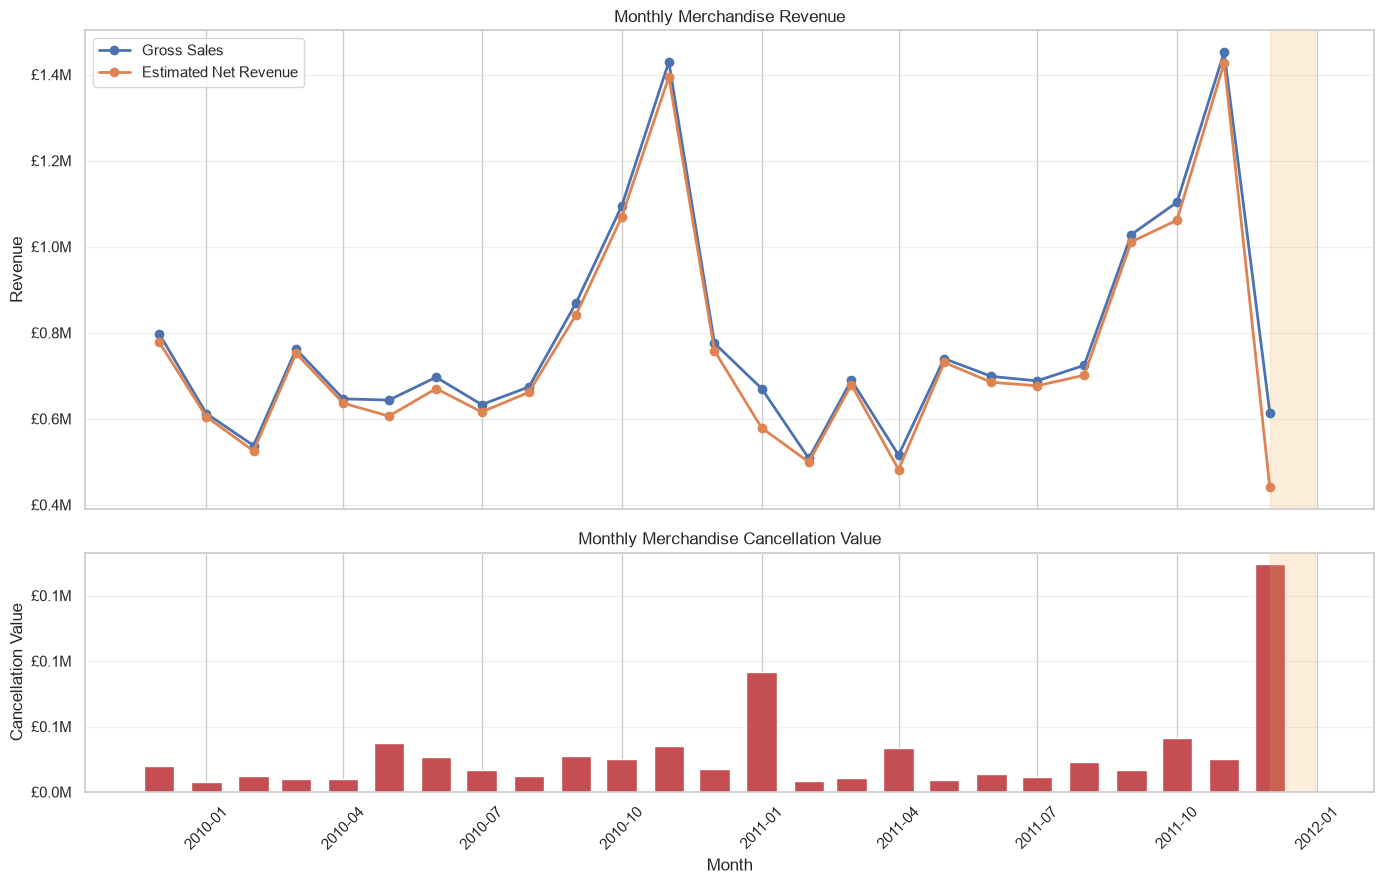

In [7]:
from matplotlib.ticker import FuncFormatter

currency_formatter = FuncFormatter(
    lambda value, position: f"£{value / 1_000_000:.1f}M"
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 9),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

axes[0].plot(
    monthly_revenue["month"],
    monthly_revenue["gross_sales"],
    marker="o",
    linewidth=2,
    label="Gross Sales",
)

axes[0].plot(
    monthly_revenue["month"],
    monthly_revenue["estimated_net_revenue"],
    marker="o",
    linewidth=2,
    label="Estimated Net Revenue",
)

axes[0].set_title("Monthly Merchandise Revenue")
axes[0].set_ylabel("Revenue")
axes[0].yaxis.set_major_formatter(currency_formatter)
axes[0].legend()

axes[1].bar(
    monthly_revenue["month"],
    monthly_revenue["cancellation_value"],
    width=20,
    color="#C44E52",
)

axes[1].set_title("Monthly Merchandise Cancellation Value")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Cancellation Value")
axes[1].yaxis.set_major_formatter(currency_formatter)

partial_month = monthly_revenue["month"].max()

for axis in axes:
    axis.axvspan(
        partial_month,
        partial_month + pd.offsets.MonthEnd(1),
        color="#F0AD4E",
        alpha=0.20,
        label="Partial December 2011",
    )
    axis.grid(axis="y", alpha=0.30)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
source_period_coverage = (
    transactions
    .groupby("source_year", observed=True)
    .agg(
        start_date=("invoice_date", "min"),
        end_date=("invoice_date", "max"),
        row_count=("invoice_no", "size"),
        unique_invoices=("invoice_no", "nunique"),
    )
    .reset_index()
    .sort_values("start_date")
)

display(source_period_coverage)

business_columns = [
    "invoice_no",
    "stock_code",
    "description",
    "quantity",
    "invoice_date",
    "unit_price",
    "customer_id",
    "country",
]

cross_source_duplicates = transactions.loc[
    transactions.duplicated(
        subset=business_columns,
        keep=False,
    )
].sort_values(
    ["invoice_date", "invoice_no", "stock_code"]
)

latest_start_date = source_period_coverage[
    "start_date"
].max()

earliest_end_date = source_period_coverage[
    "end_date"
].min()

print("Latest source start date:", latest_start_date)
print("Earliest source end date:", earliest_end_date)
print(
    "Cross-source duplicate rows:",
    len(cross_source_duplicates),
)

if not cross_source_duplicates.empty:
    display(cross_source_duplicates.head(20))

,source_year,start_date,end_date,row_count,unique_invoices
0,Year 2009-2010,2009-12-01 07:45:00,2010-11-30 19:35:00,496394,27728
1,Year 2010-2011,2010-12-01 08:26:00,2011-12-09 12:50:00,536642,25900


Latest source start date: 2010-12-01 08:26:00
Earliest source end date: 2010-11-30 19:35:00
Cross-source duplicate rows: 0


## Comparable Retail-Year Performance

Performance is compared across two complete 12-month retail periods:

- Year 2009–2010: 1 December 2009 to 30 November 2010
- Year 2010–2011: 1 December 2010 to 30 November 2011

The partial December 2011 period is excluded from this comparison.

In [9]:
complete_period_activity = merchandise_activity.loc[
    merchandise_activity["invoice_date"]
    < pd.Timestamp("2011-12-01")
].copy()

complete_period_activity["sales_customer_id"] = (
    complete_period_activity["customer_id"].where(
        complete_period_activity[
            "transaction_type"
        ].eq("Sale")
    )
)

annual_performance = (
    complete_period_activity
    .groupby("source_year", observed=True)
    .agg(
        start_date=("invoice_date", "min"),
        end_date=("invoice_date", "max"),
        gross_sales=("gross_sales_value", "sum"),
        cancellation_value=("cancellation_value", "sum"),
        estimated_net_revenue=("net_value", "sum"),
        sales_invoices=("sales_invoice_no", "nunique"),
        units_sold=("sales_units", "sum"),
        known_customers=("sales_customer_id", "nunique"),
    )
    .reset_index()
    .sort_values("start_date")
)

annual_performance["average_order_value"] = (
    annual_performance["gross_sales"]
    / annual_performance["sales_invoices"]
)

annual_performance["cancellation_rate_pct"] = (
    annual_performance["cancellation_value"]
    / annual_performance["gross_sales"]
    * 100
)

annual_performance["net_revenue_growth_pct"] = (
    annual_performance["estimated_net_revenue"]
    .pct_change()
    * 100
)

annual_performance["invoice_growth_pct"] = (
    annual_performance["sales_invoices"]
    .pct_change()
    * 100
)

display(annual_performance)

,source_year,start_date,end_date,gross_sales,cancellation_value,estimated_net_revenue,sales_invoices,units_sold,known_customers,average_order_value,cancellation_rate_pct,net_revenue_growth_pct,invoice_growth_pct
0,Year 2009-2010,2009-12-01 07:45:00,2010-11-30 19:35:00,"9,396,642.31","240,561.41","9,156,080.90",19743,5626674,4239,475.95,2.56,NaN,NaN
1,Year 2010-2011,2010-12-01 08:26:00,2011-11-30 17:42:00,"9,593,758.40","301,809.80","9,291,948.60",18956,5248680,4293,506.11,3.15,1.48,-3.99


### Retail-Year Findings

- Estimated net merchandise revenue increased by 1.48%.
- Sales invoice volume decreased by 3.99%.
- Average merchandise order value increased from £475.95 to £506.11, an increase of approximately 6.34%.
- The number of known purchasing customers increased slightly from 4,239 to 4,293.
- Units sold decreased by approximately 6.72%.
- The cancellation rate increased from 2.56% to 3.15%.

Revenue growth was therefore driven primarily by higher order values and product mix rather than increased transaction volume. The higher cancellation rate represents an area for further operational investigation.

## Country Revenue Performance

Country-level performance is evaluated using gross merchandise sales, cancellation value, estimated net revenue, invoice volume, units sold, and known customers.

In [10]:
merchandise_activity["sales_customer_id"] = (
    merchandise_activity["customer_id"].where(
        merchandise_activity[
            "transaction_type"
        ].eq("Sale")
    )
)

country_revenue = (
    merchandise_activity
    .groupby("country", observed=True)
    .agg(
        gross_sales=("gross_sales_value", "sum"),
        cancellation_value=("cancellation_value", "sum"),
        estimated_net_revenue=("net_value", "sum"),
        sales_invoices=("sales_invoice_no", "nunique"),
        units_sold=("sales_units", "sum"),
        known_customers=("sales_customer_id", "nunique"),
    )
    .reset_index()
)

country_revenue["net_revenue_share_pct"] = (
    country_revenue["estimated_net_revenue"]
    / country_revenue["estimated_net_revenue"].sum()
    * 100
)

country_revenue["cancellation_rate_pct"] = (
    country_revenue["cancellation_value"]
    / country_revenue["gross_sales"]
    * 100
)

country_revenue = country_revenue.sort_values(
    "estimated_net_revenue",
    ascending=False,
).reset_index(drop=True)

display(country_revenue.head(15))

,country,gross_sales,cancellation_value,estimated_net_revenue,sales_invoices,units_sold,known_customers,net_revenue_share_pct,cancellation_rate_pct
0,United Kingdom,"16,762,049.39","632,113.44","16,129,935.95",36183,9176130,5334,85.40,3.77
1,EIRE,"623,414.16","20,297.55","603,116.61",581,336088,3,3.19,3.26
2,Netherlands,"549,773.41","3,677.98","546,095.43",216,383625,22,2.89,0.67
3,Germany,"383,289.00","8,715.49","374,573.51",753,223089,107,1.98,2.27
4,France,"311,090.29","17,659.09","293,431.20",598,270582,93,1.55,5.68
5,Australia,"167,800.01","1,517.86","166,282.15",89,103753,15,0.88,0.90
6,Switzerland,"94,024.59","1,106.53","92,918.06",85,52612,22,0.49,1.18
7,Spain,"97,766.75","12,955.19","84,811.56",144,49996,38,0.45,13.25
8,Sweden,"86,319.14","1,973.97","84,345.17",99,88537,19,0.45,2.29
9,Denmark,"67,422.69","4,067.10","63,355.59",42,237406,12,0.34,6.03


### Country-Level Findings

- The United Kingdom dominates the business, generating 85.40% of estimated net merchandise revenue.
- International markets collectively contribute 14.60% of net revenue.
- The five largest markets contribute approximately 95.01% of total net revenue.
- EIRE is the largest international market by net revenue, but its revenue is concentrated among only three known customers.
- The Netherlands combines strong net revenue with a relatively low 0.67% cancellation rate.
- Spain has the highest cancellation rate among the leading markets at 13.25%.
- France, Denmark, Japan, and the Channel Islands also warrant cancellation monitoring.

The results indicate both geographic concentration risk and potential opportunities to expand reliable international markets.

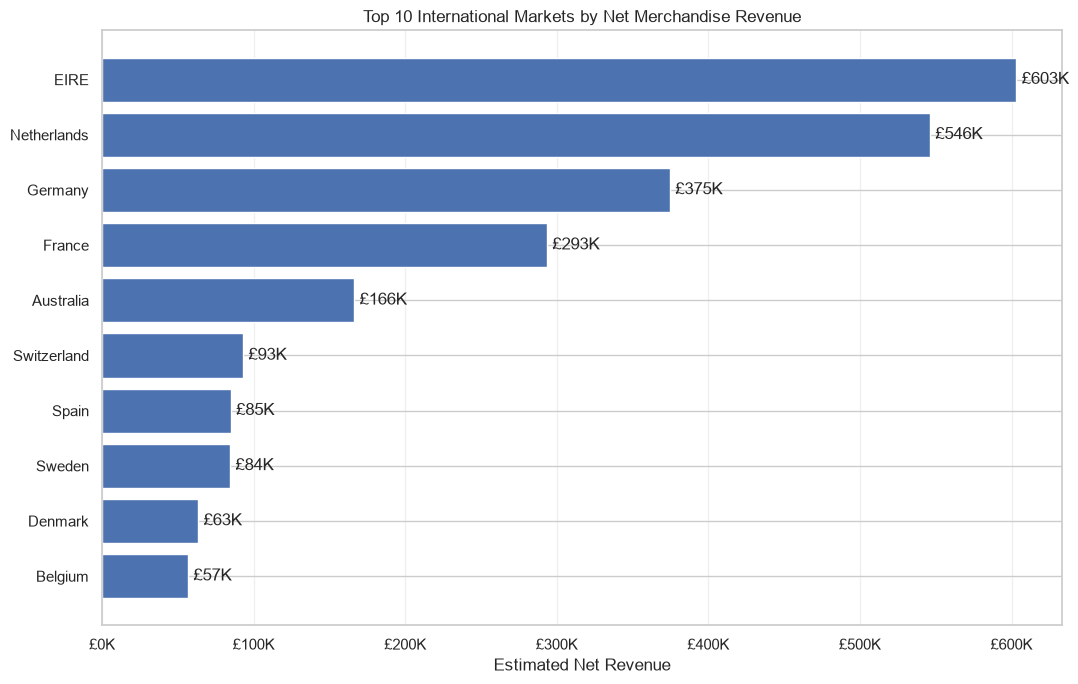

In [11]:
international_revenue = country_revenue.loc[
    ~country_revenue["country"].eq("United Kingdom")
].copy()

top_international_countries = (
    international_revenue
    .nlargest(10, "estimated_net_revenue")
    .sort_values("estimated_net_revenue")
)

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(
    top_international_countries["country"],
    top_international_countries["estimated_net_revenue"],
    color="#4C72B0",
)

ax.bar_label(
    bars,
    labels=[
        f"£{value / 1_000:,.0f}K"
        for value in top_international_countries[
            "estimated_net_revenue"
        ]
    ],
    padding=4,
)

ax.xaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position:
        f"£{value / 1_000:,.0f}K"
    )
)

ax.set_title(
    "Top 10 International Markets by Net Merchandise Revenue"
)
ax.set_xlabel("Estimated Net Revenue")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.30)

plt.tight_layout()
plt.show()

## Product Revenue Performance

Product performance is aggregated by stock code. Each stock code is assigned its most frequently occurring merchandise description to handle inconsistent historical descriptions. Gross sales and cancellation values are combined to estimate net product revenue.

In [12]:
description_frequency = (
    merchandise_sales
    .dropna(subset=["description"])
    .groupby(
        ["stock_code", "description"],
        observed=True,
    )
    .size()
    .reset_index(name="description_frequency")
    .sort_values(
        [
            "stock_code",
            "description_frequency",
            "description",
        ],
        ascending=[True, False, True],
    )
)

canonical_descriptions = (
    description_frequency
    .drop_duplicates(subset=["stock_code"])
    [["stock_code", "description"]]
)

product_sales = (
    merchandise_sales
    .groupby("stock_code", observed=True)
    .agg(
        gross_sales=("gross_sales_value", "sum"),
        units_sold=("quantity", "sum"),
        sales_invoices=("invoice_no", "nunique"),
        known_customers=("customer_id", "nunique"),
    )
    .reset_index()
)

product_cancellations = (
    merchandise_cancellations
    .groupby("stock_code", observed=True)
    .agg(
        cancellation_value=("cancellation_value", "sum"),
        cancellation_units=(
            "quantity",
            lambda values: values.abs().sum(),
        ),
        cancellation_invoices=("invoice_no", "nunique"),
    )
    .reset_index()
)

product_performance = (
    product_sales
    .merge(
        product_cancellations,
        on="stock_code",
        how="left",
    )
    .merge(
        canonical_descriptions,
        on="stock_code",
        how="left",
    )
)

product_performance[
    [
        "cancellation_value",
        "cancellation_units",
        "cancellation_invoices",
    ]
] = product_performance[
    [
        "cancellation_value",
        "cancellation_units",
        "cancellation_invoices",
    ]
].fillna(0)

product_performance["estimated_net_revenue"] = (
    product_performance["gross_sales"]
    - product_performance["cancellation_value"]
)

product_performance["cancellation_rate_pct"] = (
    product_performance["cancellation_value"]
    / product_performance["gross_sales"]
    * 100
)

product_performance["net_revenue_share_pct"] = (
    product_performance["estimated_net_revenue"]
    / product_performance["estimated_net_revenue"].sum()
    * 100
)

product_performance = (
    product_performance
    .sort_values(
        "estimated_net_revenue",
        ascending=False,
    )
    .reset_index(drop=True)
)

product_columns = [
    "stock_code",
    "description",
    "gross_sales",
    "cancellation_value",
    "estimated_net_revenue",
    "units_sold",
    "sales_invoices",
    "known_customers",
    "cancellation_rate_pct",
    "net_revenue_share_pct",
]

display(product_performance[product_columns].head(15))

,stock_code,description,gross_sales,cancellation_value,estimated_net_revenue,units_sold,sales_invoices,known_customers,cancellation_rate_pct,net_revenue_share_pct
0,22423,REGENCY CAKESTAND 3 TIER,"330,590.32","16,545.30","314,045.02",26478,3918,1314,5.00,1.66
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"261,168.73","9,387.10","251,781.63",94719,5464,1490,3.59,1.33
2,85099B,JUMBO BAG RED RETROSPOT,"182,680.98","2,168.82","180,512.16",97176,4013,978,1.19,0.96
3,47566,PARTY BUNTING,"148,318.28","1,238.55","147,079.73",28200,2674,894,0.84,0.78
4,84879,ASSORTED COLOUR BIRD ORNAMENT,"129,324.49",774.07,"128,550.42",80082,2807,1010,0.60,0.68
5,22086,PAPER CHAIN KIT 50'S CHRISTMAS,"117,760.29","1,461.70","116,298.59",35084,2018,896,1.24,0.62
6,79321,CHILLI LIGHTS,"80,540.88",635.75,"79,905.13",15841,1135,304,0.79,0.42
7,22197,SMALL POPCORN HOLDER,"79,520.20",616.58,"78,903.62",88499,2322,601,0.78,0.42
8,22386,JUMBO BAG PINK POLKADOT,"76,324.62",866.98,"75,457.64",39437,2245,601,1.14,0.40
9,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,"71,300.40",330.45,"70,969.95",31409,756,300,0.46,0.38


### Product-Level Findings

- REGENCY CAKESTAND 3 TIER is the highest-revenue product, generating £314,045.02 in estimated net revenue.
- WHITE HANGING HEART T-LIGHT HOLDER has the broadest customer and invoice reach among the leading products.
- No individual product contributes more than 1.66% of total net revenue.
- The 15 highest-revenue products collectively contribute approximately 9.43% of net revenue.
- Product revenue is therefore broadly diversified rather than concentrated in a small number of products.
- Cancellation monitoring should prioritize the leading products, particularly REGENCY CAKESTAND 3 TIER and WHITE HANGING HEART T-LIGHT HOLDER.

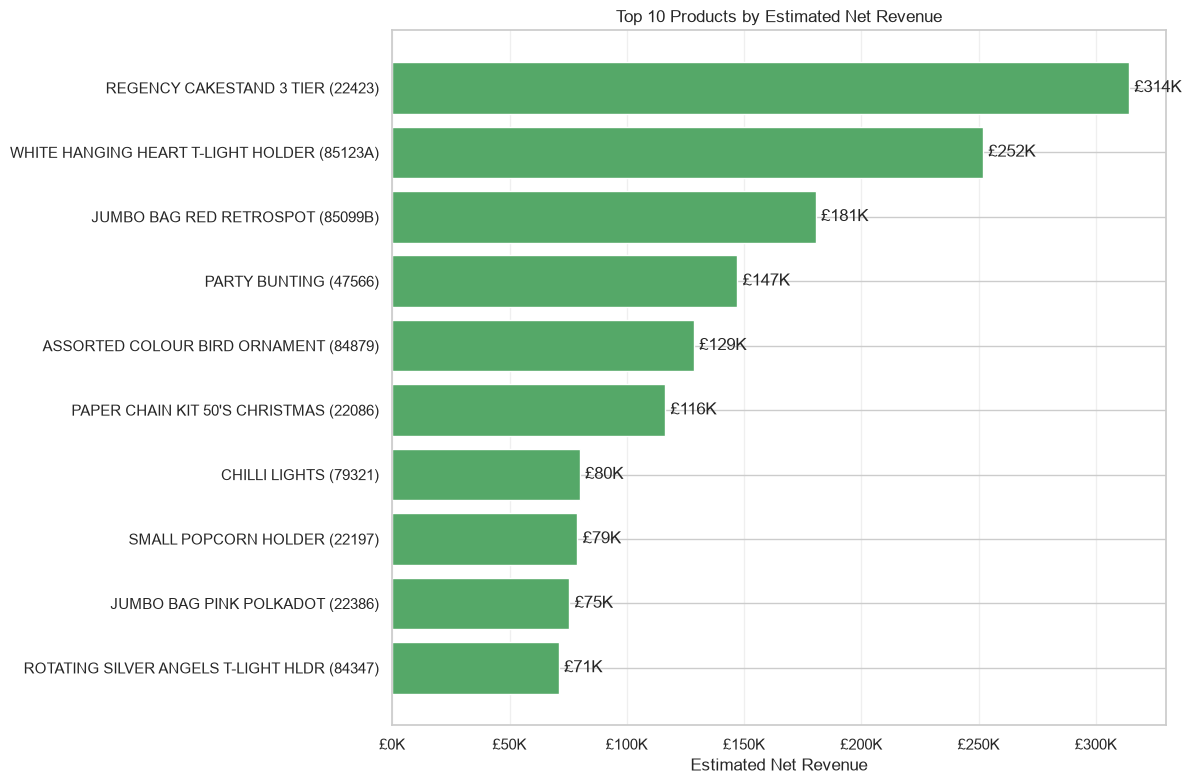

In [13]:
top_products = (
    product_performance
    .head(10)
    .sort_values("estimated_net_revenue")
    .copy()
)

top_products["product_label"] = (
    top_products["description"]
    + " ("
    + top_products["stock_code"]
    + ")"
)

fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.barh(
    top_products["product_label"],
    top_products["estimated_net_revenue"],
    color="#55A868",
)

ax.bar_label(
    bars,
    labels=[
        f"£{value / 1_000:,.0f}K"
        for value in top_products[
            "estimated_net_revenue"
        ]
    ],
    padding=4,
)

ax.xaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position:
        f"£{value / 1_000:,.0f}K"
    )
)

ax.set_title("Top 10 Products by Estimated Net Revenue")
ax.set_xlabel("Estimated Net Revenue")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.30)

plt.tight_layout()
plt.show()

## ABC Product Segmentation

Products with positive estimated net revenue are classified according to their cumulative revenue contribution:

- Class A: first 80% of net product revenue
- Class B: next 15% of net product revenue
- Class C: final 5% of net product revenue

Products with non-positive net revenue are excluded from ABC classification and retained for separate review.

In [14]:
abc_products = (
    product_performance.loc[
        product_performance[
            "estimated_net_revenue"
        ].gt(0)
    ]
    .sort_values(
        "estimated_net_revenue",
        ascending=False,
    )
    .copy()
)

positive_product_revenue = (
    abc_products["estimated_net_revenue"].sum()
)

abc_products["cumulative_net_revenue"] = (
    abc_products["estimated_net_revenue"].cumsum()
)

abc_products["cumulative_revenue_pct"] = (
    abc_products["cumulative_net_revenue"]
    / positive_product_revenue
    * 100
)

abc_products["abc_class"] = pd.cut(
    abc_products["cumulative_revenue_pct"],
    bins=[0, 80, 95, np.inf],
    labels=["A", "B", "C"],
    include_lowest=True,
)

abc_summary = (
    abc_products
    .groupby("abc_class", observed=False)
    .agg(
        product_count=("stock_code", "nunique"),
        gross_sales=("gross_sales", "sum"),
        cancellation_value=("cancellation_value", "sum"),
        estimated_net_revenue=(
            "estimated_net_revenue",
            "sum",
        ),
        units_sold=("units_sold", "sum"),
    )
    .reset_index()
)

abc_summary["product_share_pct"] = (
    abc_summary["product_count"]
    / len(abc_products)
    * 100
)

abc_summary["net_revenue_share_pct"] = (
    abc_summary["estimated_net_revenue"]
    / positive_product_revenue
    * 100
)

abc_summary["cancellation_rate_pct"] = (
    abc_summary["cancellation_value"]
    / abc_summary["gross_sales"]
    * 100
)

non_positive_products = product_performance.loc[
    product_performance[
        "estimated_net_revenue"
    ].le(0)
]

display(abc_summary)

print(
    "Products with positive net revenue:",
    len(abc_products),
)

print(
    "Products requiring separate review:",
    len(non_positive_products),
)

print(
    "Combined net value of review products:",
    f"£{non_positive_products['estimated_net_revenue'].sum():,.2f}",
)

,abc_class,product_count,gross_sales,cancellation_value,estimated_net_revenue,units_sold,product_share_pct,net_revenue_share_pct,cancellation_rate_pct
0,A,1039,"15,544,977.37","435,702.38","15,109,274.99",7694550,22.08,79.99,2.80
1,B,1256,"2,901,728.46","67,593.84","2,834,134.62",2345794,26.70,15.00,2.33
2,C,2410,"988,648.19","43,064.47","945,583.72",1066009,51.22,5.01,4.36


Products with positive net revenue: 4705
Products requiring separate review: 20
Combined net value of review products: £-300.38


### ABC Segmentation Findings

- Class A contains 1,039 products, representing 22.08% of positive-revenue products while generating 79.99% of positive net product revenue.
- Class B contains 1,256 products and contributes the next 15.00% of revenue.
- Class C contains 2,410 products—more than half of the product portfolio—but contributes only 5.01% of revenue.
- Class C also has the highest cancellation rate at 4.36%.
- Twenty additional products have non-positive net revenue, with a combined net value of −£300.38.

Class A products should receive the highest inventory-availability and demand-planning priority. Class B products represent growth opportunities, while Class C and non-positive-revenue products should be reviewed for assortment efficiency.

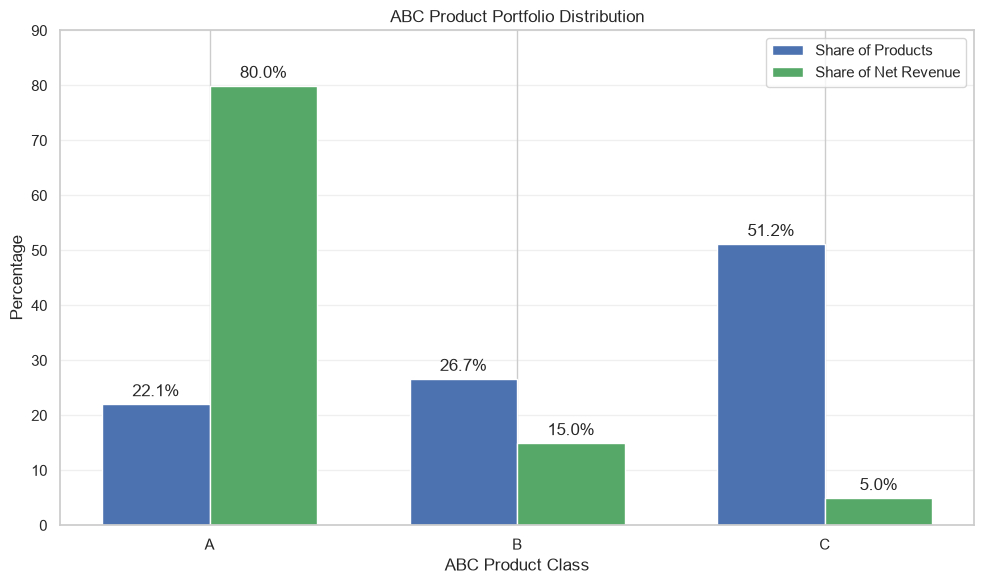

In [15]:
class_positions = np.arange(len(abc_summary))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

product_share_bars = ax.bar(
    class_positions - bar_width / 2,
    abc_summary["product_share_pct"],
    width=bar_width,
    label="Share of Products",
    color="#4C72B0",
)

revenue_share_bars = ax.bar(
    class_positions + bar_width / 2,
    abc_summary["net_revenue_share_pct"],
    width=bar_width,
    label="Share of Net Revenue",
    color="#55A868",
)

ax.bar_label(
    product_share_bars,
    labels=[
        f"{value:.1f}%"
        for value in abc_summary["product_share_pct"]
    ],
    padding=3,
)

ax.bar_label(
    revenue_share_bars,
    labels=[
        f"{value:.1f}%"
        for value in abc_summary["net_revenue_share_pct"]
    ],
    padding=3,
)

ax.set_xticks(
    class_positions,
    abc_summary["abc_class"],
)

ax.set_title("ABC Product Portfolio Distribution")
ax.set_xlabel("ABC Product Class")
ax.set_ylabel("Percentage")
ax.set_ylim(0, 90)
ax.legend()
ax.grid(axis="y", alpha=0.30)

plt.tight_layout()
plt.show()

## Customer Identification Coverage

Customer segmentation and retention analysis require a valid customer ID. Merchandise sales are therefore divided into identified-customer and anonymous-customer transactions to quantify analytical coverage.

Anonymous sales remain included in overall revenue reporting but are excluded from customer-level analysis.

In [16]:
customer_coverage_data = merchandise_sales.assign(
    customer_status=np.where(
        merchandise_sales["customer_id"].notna(),
        "Identified Customer",
        "Anonymous Customer",
    )
)

customer_coverage = (
    customer_coverage_data
    .groupby("customer_status", observed=True)
    .agg(
        row_count=("invoice_no", "size"),
        sales_invoices=("invoice_no", "nunique"),
        units_sold=("quantity", "sum"),
        gross_sales=("gross_sales_value", "sum"),
        known_customers=("customer_id", "nunique"),
    )
    .reset_index()
)

customer_coverage["sales_row_share_pct"] = (
    customer_coverage["row_count"]
    / len(merchandise_sales)
    * 100
)

customer_coverage["invoice_share_pct"] = (
    customer_coverage["sales_invoices"]
    / merchandise_sales["invoice_no"].nunique()
    * 100
)

customer_coverage["gross_sales_share_pct"] = (
    customer_coverage["gross_sales"]
    / merchandise_sales["gross_sales_value"].sum()
    * 100
)

customer_coverage = customer_coverage.sort_values(
    "gross_sales",
    ascending=False,
).reset_index(drop=True)

display(customer_coverage)

,customer_status,row_count,sales_invoices,units_sold,gross_sales,known_customers,sales_row_share_pct,invoice_share_pct,gross_sales_share_pct
0,Identified Customer,776595,36593,10498695,"17,029,612.74",5852,77.40,92.61,86.86
1,Anonymous Customer,226761,2922,689306,"2,575,278.90",0,22.60,7.39,13.14


### Customer Coverage Findings

- Identified customers account for 86.86% of gross merchandise sales and 92.61% of sales invoices.
- A total of 5,852 known customers are available for customer-level analysis.
- Anonymous transactions contribute £2,575,278.90, representing 13.14% of gross merchandise sales.
- Anonymous sales are retained in overall revenue reporting but excluded from RFM, cohort, and retention analysis.
- The high identified-revenue coverage provides a reliable foundation for customer segmentation.

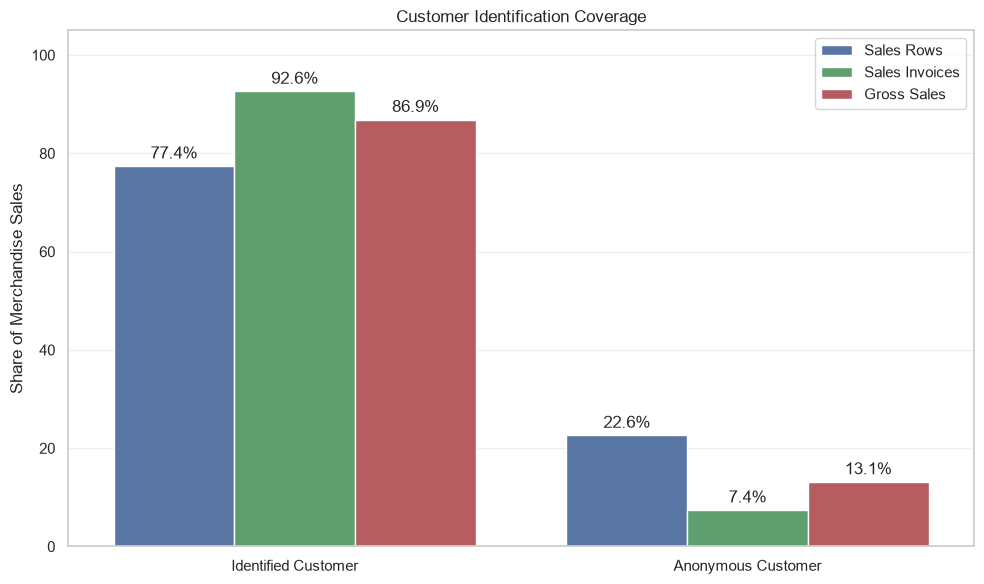

In [17]:
coverage_chart_data = customer_coverage.melt(
    id_vars="customer_status",
    value_vars=[
        "sales_row_share_pct",
        "invoice_share_pct",
        "gross_sales_share_pct",
    ],
    var_name="coverage_metric",
    value_name="percentage",
)

coverage_chart_data["coverage_metric"] = (
    coverage_chart_data["coverage_metric"].map(
        {
            "sales_row_share_pct": "Sales Rows",
            "invoice_share_pct": "Sales Invoices",
            "gross_sales_share_pct": "Gross Sales",
        }
    )
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=coverage_chart_data,
    x="customer_status",
    y="percentage",
    hue="coverage_metric",
    palette=["#4C72B0", "#55A868", "#C44E52"],
    ax=ax,
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
    )

ax.set_title("Customer Identification Coverage")
ax.set_xlabel("")
ax.set_ylabel("Share of Merchandise Sales")
ax.set_ylim(0, 105)
ax.legend(title="")
ax.grid(axis="y", alpha=0.30)

plt.tight_layout()
plt.show()

## Cancellation-Driver Analysis

Cancellation value is analyzed at invoice level to determine whether cancellations are broadly distributed or concentrated among a small number of unusually large reversals.

In [18]:
cancellation_invoice_summary = (
    merchandise_cancellations
    .groupby("invoice_no", observed=True)
    .agg(
        cancellation_date=("invoice_date", "min"),
        customer_id=("customer_id", "first"),
        country=("country", "first"),
        cancelled_lines=("stock_code", "size"),
        cancelled_products=("stock_code", "nunique"),
        cancelled_units=(
            "quantity",
            lambda values: values.abs().sum(),
        ),
        cancellation_value=("cancellation_value", "sum"),
    )
    .reset_index()
    .sort_values(
        "cancellation_value",
        ascending=False,
    )
    .reset_index(drop=True)
)

largest_two_cancellation_share = (
    cancellation_invoice_summary
    .head(2)["cancellation_value"]
    .sum()
    / cancellation_invoice_summary[
        "cancellation_value"
    ].sum()
    * 100
)

print(
    "Cancellation invoices:",
    f"{len(cancellation_invoice_summary):,}",
)

print(
    "Median cancellation invoice value:",
    f"£{cancellation_invoice_summary['cancellation_value'].median():,.2f}",
)

print(
    "Largest two invoices' share of cancellation value:",
    f"{largest_two_cancellation_share:.2f}%",
)

display(cancellation_invoice_summary.head(10))

Cancellation invoices: 7,406
Median cancellation invoice value: £15.90
Largest two invoices' share of cancellation value: 34.29%


,invoice_no,cancellation_date,customer_id,country,cancelled_lines,cancelled_products,cancelled_units,cancellation_value
0,C581484,2011-12-09 09:27:00,16446,United Kingdom,1,1,80995,"168,469.60"
1,C541433,2011-01-18 10:17:00,12346,United Kingdom,1,1,74215,"77,183.60"
2,C550456,2011-04-18 13:08:00,15749,United Kingdom,5,5,9014,"22,998.40"
3,C524235,2010-09-28 11:02:00,14277,France,45,45,87167,"11,880.84"
4,C570556,2011-10-11 11:10:00,16029,United Kingdom,9,8,4896,"9,466.56"
5,C513771,2010-06-28 13:49:00,16754,United Kingdom,14,14,6584,"7,500.32"
6,C529352,2010-10-28 09:32:00,17450,United Kingdom,9,9,2760,"6,325.08"
7,C508132,2010-05-13 10:54:00,12931,United Kingdom,11,11,3564,"4,815.80"
8,C508134,2010-05-13 10:56:00,12931,United Kingdom,11,11,3560,"4,798.80"
9,C527790,2010-10-19 11:12:00,12454,Spain,8,8,2232,"4,733.52"


### Cancellation Findings

- The dataset contains 7,406 merchandise cancellation invoices.
- The median cancellation invoice value is only £15.90.
- The two largest cancellation invoices contribute 34.29% of total merchandise cancellation value.
- These two invoices are complete reversals of unusually large sales rather than evidence of broadly high cancellation values.
- The headline cancellation rate should therefore be interpreted together with an outlier sensitivity measure.

In [19]:
total_cancellation_value = (
    cancellation_invoice_summary[
        "cancellation_value"
    ].sum()
)

largest_two_value = (
    cancellation_invoice_summary
    .head(2)["cancellation_value"]
    .sum()
)

cancellation_value_without_largest_two = (
    total_cancellation_value
    - largest_two_value
)

headline_cancellation_rate = (
    total_cancellation_value
    / gross_sales
    * 100
)

sensitivity_cancellation_rate = (
    cancellation_value_without_largest_two
    / gross_sales
    * 100
)

cancellation_sensitivity = pd.DataFrame(
    {
        "Measure": [
            "Total cancellation value",
            "Largest two cancellation invoices",
            "Cancellation value excluding largest two",
            "Headline cancellation rate",
            "Sensitivity rate excluding largest two",
        ],
        "Result": [
            f"£{total_cancellation_value:,.2f}",
            f"£{largest_two_value:,.2f}",
            (
                f"£{cancellation_value_without_largest_two:,.2f}"
            ),
            f"{headline_cancellation_rate:.2f}%",
            f"{sensitivity_cancellation_rate:.2f}%",
        ],
    }
)

display(cancellation_sensitivity)

,Measure,Result
0,Total cancellation value,"£716,462.57"
1,Largest two cancellation invoices,"£245,653.20"
2,Cancellation value excluding largest two,"£470,809.37"
3,Headline cancellation rate,3.65%
4,Sensitivity rate excluding largest two,2.40%


## Export Revenue Analysis Tables

The revenue-analysis outputs are exported as reusable CSV tables for SQL validation, Snowflake loading, and Tableau dashboard development.

In [20]:
analytics_path = (
    project_root
    / "data"
    / "processed"
    / "analytics"
)

analytics_path.mkdir(
    parents=True,
    exist_ok=True,
)

abc_class_lookup = dict(
    zip(
        abc_products["stock_code"],
        abc_products["abc_class"].astype("string"),
    )
)

product_performance_export = product_performance.copy()

product_performance_export["abc_class"] = (
    product_performance_export["stock_code"]
    .map(abc_class_lookup)
    .fillna("Review")
)

revenue_kpis_export = pd.DataFrame(
    {
        "kpi": [
            "gross_merchandise_sales",
            "merchandise_cancellation_value",
            "estimated_net_merchandise_revenue",
            "sales_invoices",
            "units_sold",
            "known_customers",
            "average_merchandise_order_value",
            "cancellation_rate_by_value",
        ],
        "value": [
            gross_sales,
            cancellation_value,
            estimated_net_revenue,
            sales_orders,
            units_sold,
            known_customers,
            average_order_value,
            cancellation_rate,
        ],
        "unit": [
            "GBP",
            "GBP",
            "GBP",
            "Count",
            "Count",
            "Count",
            "GBP",
            "Percentage",
        ],
    }
)

analysis_exports = {
    "revenue_kpis.csv": revenue_kpis_export,
    "monthly_revenue.csv": monthly_revenue,
    "annual_performance.csv": annual_performance,
    "country_revenue.csv": country_revenue,
    "product_performance.csv": product_performance_export,
    "abc_summary.csv": abc_summary,
    "customer_coverage.csv": customer_coverage,
    "cancellation_invoices.csv": cancellation_invoice_summary,
}

export_records = []

for file_name, dataframe in analysis_exports.items():
    export_path = analytics_path / file_name

    dataframe.to_csv(
        export_path,
        index=False,
        date_format="%Y-%m-%d %H:%M:%S",
    )

    export_records.append(
        {
            "file": str(
                export_path.relative_to(project_root)
            ),
            "rows": len(dataframe),
            "size_kb": (
                export_path.stat().st_size / 1024
            ),
        }
    )

analysis_export_manifest = pd.DataFrame(
    export_records
)

display(analysis_export_manifest)

print(
    "Revenue analysis exports completed successfully."
)

,file,rows,size_kb
0,data\processed\analytics\revenue_kpis.csv,8,0.36
1,data\processed\analytics\monthly_revenue.csv,25,2.52
2,data\processed\analytics\annual_performance.csv,2,0.53
3,data\processed\analytics\country_revenue.csv,43,3.62
4,data\processed\analytics\product_performance.csv,4725,536.66
5,data\processed\analytics\abc_summary.csv,3,0.46
6,data\processed\analytics\customer_coverage.csv,2,0.35
7,data\processed\analytics\cancellation_invoices...,7406,450.74


Revenue analysis exports completed successfully.


## Revenue Analysis Summary

### Executive performance

- Gross merchandise sales: £19,604,891.64
- Merchandise cancellation value: £716,462.57
- Estimated net merchandise revenue: £18,888,429.07
- Sales invoices: 39,515
- Units sold: 11,188,001
- Known purchasing customers: 5,852
- Average merchandise order value: £496.14
- Headline cancellation rate: 3.65%

### Revenue trend

- Revenue exhibits strong seasonality, with the highest activity occurring between September and November.
- Comparable retail-year net revenue increased by 1.48%.
- Sales invoice volume decreased by 3.99%.
- Average order value increased by approximately 6.34%.
- Units sold decreased by approximately 6.72%.
- Revenue growth was therefore driven by higher-value orders and product mix rather than increased transaction volume.

### Geographic performance

- The United Kingdom contributes 85.40% of estimated net merchandise revenue.
- The five largest countries contribute approximately 95.01% of net revenue.
- EIRE is the largest international market but is highly concentrated among only three known customers.
- The Netherlands combines strong international revenue with a low cancellation rate.
- Spain has a comparatively high 13.25% cancellation rate.

### Product performance

- REGENCY CAKESTAND 3 TIER is the leading product, generating £314,045.02 in estimated net revenue.
- No individual product contributes more than 1.66% of total net revenue.
- The 15 leading products contribute approximately 9.43%, indicating a diversified product portfolio.
- Class A contains 22.08% of positive-revenue products and generates 79.99% of product revenue.
- Class C contains 51.22% of products but generates only 5.01% of revenue.

### Customer-data coverage

- Identified customers contribute 86.86% of gross merchandise sales.
- Anonymous transactions contribute 13.14% of gross merchandise sales.
- Anonymous revenue remains in company-level reporting but is excluded from customer segmentation and retention analysis.

### Cancellation behavior

- The dataset contains 7,406 merchandise cancellation invoices.
- Median cancellation invoice value is £15.90.
- The two largest complete reversals contribute 34.29% of cancellation value.
- The headline cancellation rate is 3.65%.
- Excluding the two extreme reversals for sensitivity analysis reduces the rate to 2.40%.

### Business recommendations

1. Prioritize availability and demand planning for Class A products.
2. Develop Class B products as potential future revenue leaders.
3. Review Class C and non-positive-revenue products for assortment efficiency.
4. Investigate cancellation drivers in Spain and other high-rate markets.
5. Reduce dependence on the United Kingdom by expanding reliable international markets.
6. Improve customer-ID capture to increase retention-analysis coverage.
7. Track both headline and outlier-adjusted cancellation measures.